In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import sys
import os
import joblib

In [12]:
def fragility(node_type, depth):
    if node_type == 'road':
        return 1 / (1 + np.exp(-10 * (depth - 0.3)))
    elif node_type in ('substation', 'power'):
        return 1 / (1 + np.exp(-6 * (depth - 1.2)))
    elif node_type == 'hospital':
        return 1 / (1 + np.exp(-4 * (depth - 1.5)))
    return 0.0

In [13]:
def load_data(csv_path, graph_path):
    print("Loading datasets...")
    df = pd.read_csv(csv_path)
    with open(graph_path, 'rb') as f:
        graph = pickle.load(f)
        
    # Standardize type naming safely
    for n, d in graph.nodes(data=True):
        if 'type' in d and 'node_type' not in d:
            d['node_type'] = d['type']
            
    return df, graph

In [14]:
def preprocess_data(df):
    print("Preprocessing data for machine learning model...")
    le = LabelEncoder()
    df['node_type_encoded'] = le.fit_transform(df['node_type'])
    
    features = [
        'node_type_encoded', 'elevation', 'flood_depth', 'fragility_score',
        'degree_centrality', 'betweenness_centrality', 'redistributed_load',
        'overload_ratio', 'failed_neighbors_prev', 'cross_layer_dependency_stress',
        'distance_from_epicenter', 'was_failed_prev',
        'betweenness_centrality_log', 'redistributed_load_log', 'overload_ratio_log'
    ]
    
    X = df[features].copy()
    X.fillna(0.0, inplace=True)
    y = df['target_failed']
    
    return X, y, le, features

In [15]:
def train_model(X_train, y_train):
    print("Training RandomForest model... (This will be quick)")
    # Lightweight bounds to prevent aggressive overhang and memory locks
    clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    return clf

In [16]:
def evaluate_model(clf, X_test, y_test):
    print("\n--- Evaluate Model Performance ---")
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("----------------------------------\n")
    return acc, f1, cm

In [17]:
def predict_with_intensity(clf, graph, df, le, features, intensity, n_timesteps=10):
    print(f"\nSimulating {n_timesteps}-step cascade at intensity multiplier: {intensity}x")
    
    baseline_stats = df[df['timestep'] == 0].drop_duplicates(subset=['node_id']).set_index('node_id')
    
    all_elevs = [d.get('elevation_m', 0.0) for _, d in graph.nodes(data=True)]
    max_elev = max(all_elevs) if max(all_elevs) > 0 else 1.0
    
    base_depths = {}
    for n, d in graph.nodes(data=True):
        bd = d.get('flood_depth_m', 0.0)
        if bd == 0.0:
            elev = d.get('elevation_m', max_elev)
            bd = max(0.05, (1.0 - elev / max_elev) * 1.5)
        base_depths[n] = bd
    
    # Cascade state
    failed_set = set()
    node_list = list(graph.nodes())
    neighbors_map = {n: list(graph.neighbors(n)) for n in node_list}
    
    final_pred = {n: 0 for n in node_list}
    
    for t in range(n_timesteps):
        node_data = []
        
        for n, d in graph.nodes(data=True):
            node_type = d.get('node_type', 'road')
            
            new_depth = base_depths[n] * intensity
            frag_score = fragility(node_type, new_depth)
            
            was_fail = int(n in failed_set)
            failed_neighbors = sum(1 for ng in neighbors_map[n] if ng in failed_set)
            
            if n in baseline_stats.index:
                row = baseline_stats.loc[n]
                elev = row['elevation']
                deg = row['degree_centrality']
                betw = row['betweenness_centrality']
                betw_log = row['betweenness_centrality_log']
                dist_epi = row['distance_from_epicenter']
                ovrl = min(row['overload_ratio'] * (1 + 0.3 * t), 5.0)
                ovrl_log = np.log1p(ovrl)
                dep_stress = min(row['cross_layer_dependency_stress'] + 0.1 * failed_neighbors, 1.0)
            else:
                elev = d.get('elevation_m', 0.0)
                deg = betw = betw_log = dist_epi = ovrl = ovrl_log = dep_stress = 0.0
            
            redist = 0.0
            redist_log = 0.0
            
            try:
                enc_type = le.transform([node_type])[0]
            except ValueError:
                enc_type = le.transform(['road'])[0]
            
            node_data.append({
                'node_id': n,
                'node_type_encoded': enc_type,
                'elevation': elev,
                'flood_depth': new_depth,
                'fragility_score': frag_score,
                'degree_centrality': deg,
                'betweenness_centrality': betw,
                'redistributed_load': redist,
                'overload_ratio': ovrl,
                'failed_neighbors_prev': failed_neighbors,
                'cross_layer_dependency_stress': dep_stress,
                'distance_from_epicenter': dist_epi,
                'was_failed_prev': was_fail,
                'betweenness_centrality_log': betw_log,
                'redistributed_load_log': redist_log,
                'overload_ratio_log': ovrl_log
            })
        
        pred_df = pd.DataFrame(node_data)
        X_pred = pred_df[features].copy()
        
        proba = clf.predict_proba(X_pred)[:, 1]
        preds = (proba >= 0.5).astype(int)
        pred_df['predicted_failure'] = preds
        pred_df['failure_prob'] = proba
        
        for i, row in pred_df.iterrows():
            if row['predicted_failure'] == 1:
                failed_set.add(row['node_id'])
        
        print(f"  Timestep {t+1}/{n_timesteps}: {len(failed_set)} cumulative failures")
        final_pred_df = pred_df.copy()
    
    final_pred_df['predicted_failure'] = final_pred_df['node_id'].apply(lambda n: int(n in failed_set))
    
    return final_pred_df

In [18]:
def visualize_graph(graph, pred_df, intensity):
    print("Rendering graphical representation layer...")
    
    pred_map = pred_df.set_index('node_id')['predicted_failure'].to_dict()
    colors = []
    failed_count = 0
    
    for n in graph.nodes():
        if pred_map.get(n, 0) == 1:
            colors.append('red')
            failed_count += 1
        else:
            colors.append('mediumseagreen')
            
    print(f"Total Graph Failures Mapped: {failed_count} / {len(graph)}")
            
    pos = {}
    for n, d in graph.nodes(data=True):
        if 'x' in d and 'y' in d:
            pos[n] = (d['x'], d['y'])
            
    if len(pos) < len(graph):
        pos = nx.spring_layout(graph, seed=42)
        
    plt.figure(figsize=(12, 12))
    plt.title(f'Predicted Cascade Fracture (Intensity x{intensity})', fontsize=18, fontweight='bold', pad=20)
    
    nx.draw_networkx_edges(graph, pos, alpha=0.1, edge_color='gray')
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=15, alpha=0.9, edgecolors='black', linewidths=0.2)
    
    plt.scatter([], [], c='red', s=50, label='Predicted Failure', edgecolors='black')
    plt.scatter([], [], c='mediumseagreen', s=50, label='Predicted Survival', edgecolors='black')
    plt.legend(frameon=True, fontsize='large', loc='upper right')
    
    plt.axis('off')
    plt.tight_layout()
    
    output_img = f'cascade_prediction_img_{intensity}.png'
    plt.savefig(output_img, dpi=300, facecolor='white')
    print(f"Success! Prediction Image saved as '{output_img}'")

In [19]:
def main():
    try:
        csv_path = 'synthetic_cascade_dataset.csv'
        graph_path = 'cascadewatch_graph.pkl'
        
        df, graph = load_data(csv_path, graph_path)
        X, y, le, features = preprocess_data(df)
        
        model_path = 'rf_cascade_model.joblib'
        le_path = 'label_encoder.joblib'
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        if os.path.exists(model_path) and os.path.exists(le_path):
            try:
                clf = joblib.load(model_path)
                le_loaded = joblib.load(le_path)
                le = le_loaded
                print("Model loaded successfully. Evaluating on test set...")
            except Exception:
                print("Saved model is incompatible. Retraining...")
                os.remove(model_path)
                os.remove(le_path)
                clf = train_model(X_train, y_train)
                print(f"Saving trained model to '{model_path}'...")
                joblib.dump(clf, model_path)
                joblib.dump(le, le_path)
        else:
            clf = train_model(X_train, y_train)
            print(f"Saving trained model to '{model_path}'...")
            joblib.dump(clf, model_path)
            joblib.dump(le, le_path)
        
        evaluate_model(clf, X_test, y_test)
        
        print("\n--- Flood Intensity Input ---")
        print("This is a dimensionless multiplier applied to each node's base flood depth (measured in metres).")
        print("  1.0 = baseline flood conditions (as recorded in sensor data)")
        print("  2.0 = flood depth doubled across all nodes")
        print("  5.0 = severe flood (5x baseline depth)")
        print("  10.0 = extreme flood event (10x baseline depth)")
        user_in = input("\nEnter flood intensity multiplier: ")
        try:
            if user_in.strip() == "":
                intensity = 1.5
            else:
                intensity = float(user_in)
        except ValueError:
            print("Invalid input, defaulting to 1.5")
            intensity = 1.5
                
        pred_df = predict_with_intensity(clf, graph, df, le, features, intensity)
        
        failed_df = pred_df[pred_df['predicted_failure'] == 1].copy()
        print(f"\n======== TARGET DAMAGE SUMMARY (Intensity {intensity}x) ========")
        
        from collections import Counter
        total_by_type = Counter(d.get('node_type', 'unknown') for _, d in graph.nodes(data=True))
        
        if len(failed_df) > 0:
            failed_df['node_type_str'] = le.inverse_transform(failed_df['node_type_encoded'].astype(int))
            counts = failed_df['node_type_str'].value_counts()
            
            print(f"Total Structural Failures: {len(failed_df)} / {len(pred_df)}")
            print("\nFailure Breakdown (failed / total of that type):")
            for ntype, count in counts.items():
                total = total_by_type.get(ntype, '?')
                pct = (count / total * 100) if isinstance(total, int) else 0
                print(f"  --> {ntype.capitalize()}: {count} / {total} ({pct:.1f}% of all {ntype}s)")
                
            print("\nDetailed Failed Node Identifiers:")
            for ntype in counts.index:
                type_ids = failed_df[failed_df['node_type_str'] == ntype]['node_id'].tolist()
                print(f"{ntype.capitalize()}: {type_ids}\n")
        else:
            print("\nNode Type Totals in Network:")
            for ntype, total in sorted(total_by_type.items()):
                print(f"  {ntype.capitalize()}: {total} nodes total")
            print(f"\nZERO infrastructure failures detected! The grid is fully resilient at this scale. (0 / {len(pred_df)} failures)")
            
        print("===============================================================\n")
        
        visualize_graph(graph, pred_df, intensity)
        
    except Exception as e:
        print(f"Error during execution: {str(e)}")

Loading datasets...
Preprocessing data for machine learning model...
Model loaded successfully. Evaluating on test set...

--- Evaluate Model Performance ---
Accuracy: 0.6711
F1-Score: 0.7136
Confusion Matrix:
 [[ 6433  6005]
 [ 2085 10077]]
----------------------------------


--- Flood Intensity Input ---
This is a dimensionless multiplier applied to each node's base flood depth (measured in metres).
  1.0 = baseline flood conditions (as recorded in sensor data)
  2.0 = flood depth doubled across all nodes
  5.0 = severe flood (5x baseline depth)
  10.0 = extreme flood event (10x baseline depth)


/Users/kritimadumadukala/Desktop/DM/PROJECT/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/kritimadumadukala/Desktop/DM/PROJECT/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/kritimadumadukala/Desktop/DM/PROJECT/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarn


Simulating 10-step cascade at intensity multiplier: 10.0x
  Timestep 1/10: 23 cumulative failures
  Timestep 2/10: 36 cumulative failures
  Timestep 3/10: 69 cumulative failures
  Timestep 4/10: 88 cumulative failures
  Timestep 5/10: 99 cumulative failures
  Timestep 6/10: 129 cumulative failures
  Timestep 7/10: 175 cumulative failures
  Timestep 8/10: 201 cumulative failures
  Timestep 9/10: 221 cumulative failures
  Timestep 10/10: 235 cumulative failures

======== TARGET DAMAGE SUMMARY (Intensity 10.0x) ========
Total Structural Failures: 235 / 820

Failure Breakdown (failed / total of that type):
  --> Hospital: 126 / 298 (42.3% of all hospitals)
  --> Road: 100 / 511 (19.6% of all roads)
  --> Power: 9 / 11 (81.8% of all powers)

Detailed Failed Node Identifiers:
Hospital: [560, 563, 567, 569, 570, 571, 573, 576, 577, 580, 594, 597, 601, 602, 605, 610, 614, 616, 619, 621, 623, 625, 628, 632, 633, 638, 643, 647, 657, 666, 667, 669, 671, 672, 673, 674, 675, 681, 682, 683, 684, 68

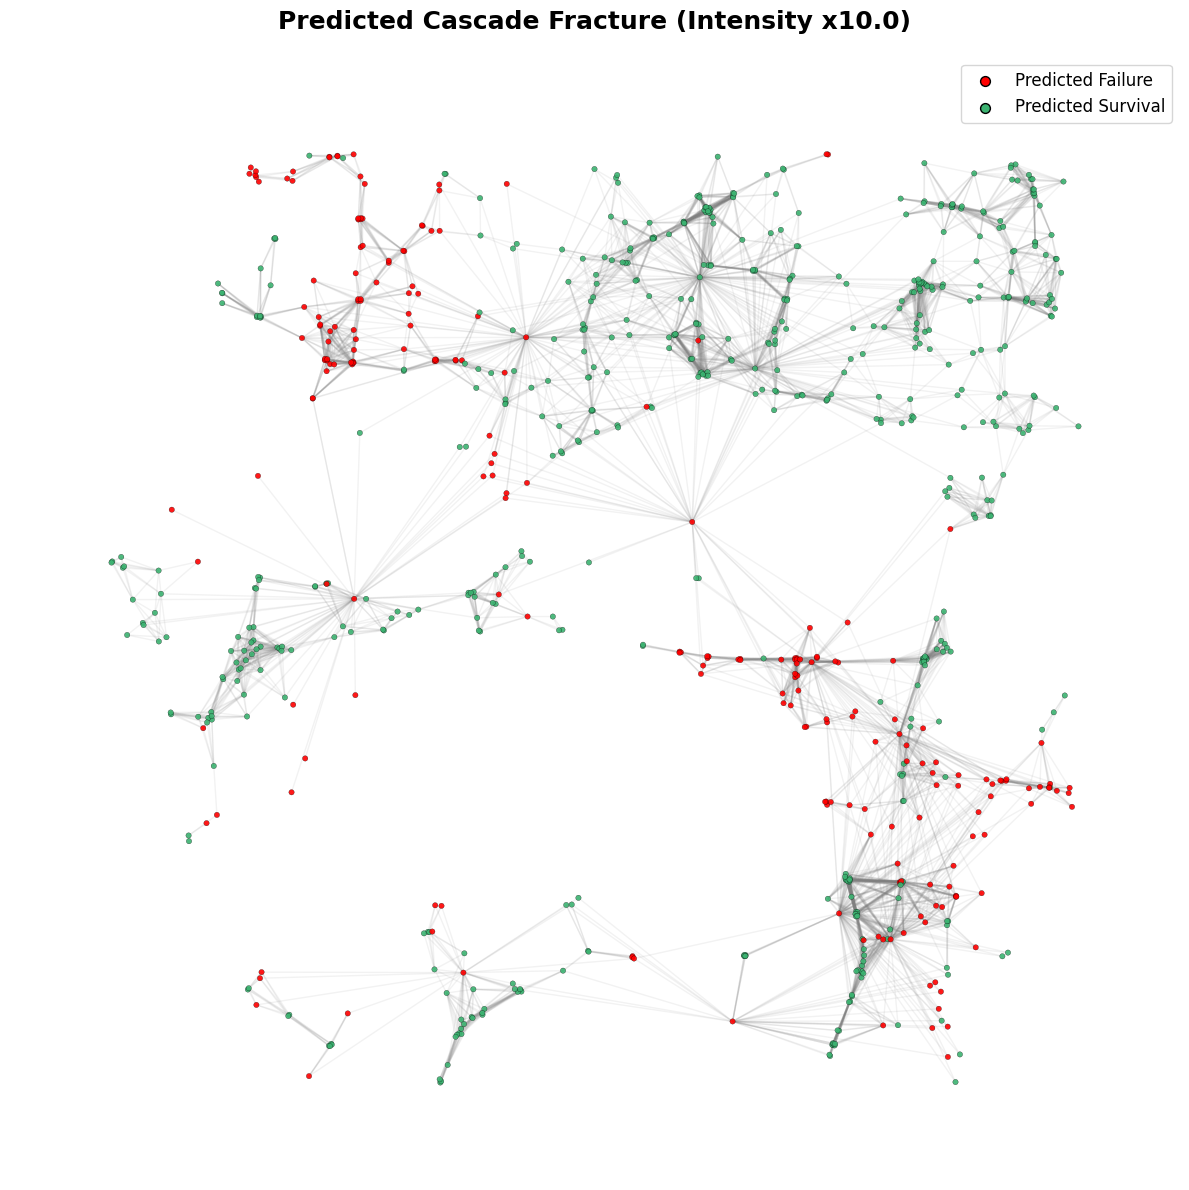

In [20]:
if __name__ == '__main__':
    main()